# Multivariate Random Variables

Individual distributions describe each variable separately. A joint distribution also describes how their values occur together. This distinction matters when asset returns are combined, because portfolio dispersion depends on joint movement.

I first define random vectors and their joint, marginal, and conditional distributions. Covariance then provides a summary of linear dependence, which connects directly to the moments of linear combinations.

Repeated observations are assumed to be iid vectors. Components within a vector can be dependent. Independence across observations does not mean independence across assets.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from finstats.multivariate import covariance, correlation, covariance_matrix, linear_combination_mean, linear_combination_variance

## 1. From random variables to random vectors

A random vector collects $K$ random variables:
$$\mathbf X=(X_1,\ldots,X_K)^\top.$$
Its realization is $\mathbf x=(x_1,\ldots,x_K)^\top$. The components might represent asset returns over a common horizon. Before observation, the entire vector is random.

The joint CDF is
$$F_{\mathbf X}(\mathbf x)=P(X_1\le x_1,\ldots,X_K\le x_K).$$
When the vector admits a joint density, its bivariate PDF satisfies
$$f_{X_1,X_2}(x_1,x_2)=\frac{\partial^2F_{X_1,X_2}(x_1,x_2)}{\partial x_1\partial x_2},$$
where the derivatives exist. It is nonnegative and integrates to one. Probabilities come from integration over regions:
$$P(\mathbf X\in B)=\iint_B f_{X_1,X_2}(x_1,x_2)\,dx_1\,dx_2.$$

## 2. Marginal distributions

A marginal density is obtained by integrating out the other components:
$$f_{X_1}(x_1)=\int_{\mathbb R}f_{X_1,X_2}(x_1,x_2)\,dx_2,\qquad
f_{X_2}(x_2)=\int_{\mathbb R}f_{X_1,X_2}(x_1,x_2)\,dx_1.$$
This retains the distribution of one component while removing information about joint behaviour.

## 3. Conditional distributions

When $f_{X_1}(x_1)>0$, the conditional density is
$$f_{X_2\mid X_1=x_1}(x_2)=\frac{f_{X_1,X_2}(x_1,x_2)}{f_{X_1}(x_1)}.$$
It describes uncertainty about $X_2$ given the observed value of $X_1$. Marginalization averages over the first variable, whereas conditioning fixes its value.

The denominator normalizes the selected slice:
$$\int_{\mathbb R}f_{X_2\mid X_1=x_1}(x_2)\,dx_2=1.$$
For a continuous variable, $P(X_1=x_1)=0$. The density ratio does not divide by that point probability.

### A joint uniform distribution

Consider the density
$$f_{X,Y}(x,y)=\frac1{2c},\qquad 0\le x\le1,\quad x-c\le y\le x+c,$$
with $c>0$, and zero outside this band. Integrating over the other component gives
$$f_X(x)=1\quad(0\le x\le1),$$
$$f_Y(y)=\frac{\max\{0,\min(1,y+c)-\max(0,y-c)\}}{2c}.$$
The numerator is the length of the band at a fixed $y$. Dividing the joint density by $f_X(x)$ gives
$$Y\mid X=x\sim U(x-c,x+c),\qquad E[Y\mid X=x]=x,\qquad
\operatorname{Var}(Y\mid X=x)=c^2/3.$$

For illustration, I use $c=1$ and $x=.25$. The joint support, marginal density and conditional density show how conditioning changes the range of possible values of $Y$.

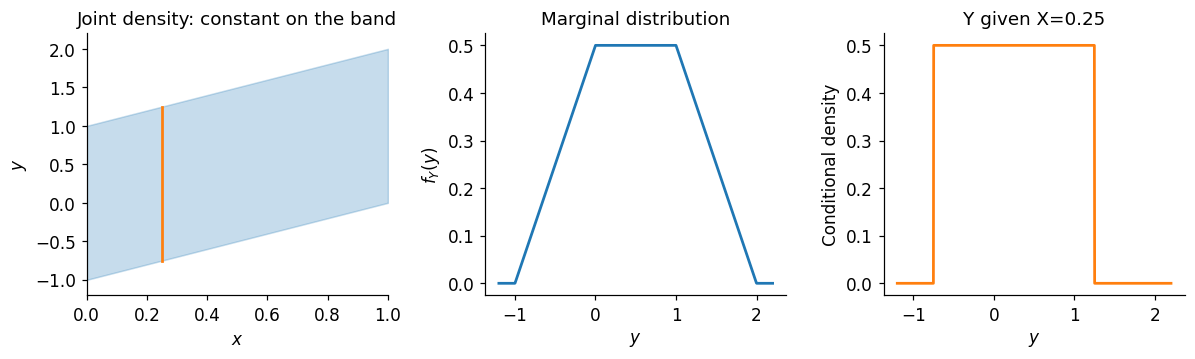

Conditional mean: 0.25, conditional variance: 0.3333


In [2]:
c, observed_x = 1., .25
x_band = np.linspace(0, 1, 501)
y_band = np.linspace(-1.2, 2.2, 1001)
marginal_y = np.maximum(0, np.minimum(1, y_band+c)-np.maximum(0, y_band-c))/(2*c)
conditional_y = ((y_band >= observed_x-c) & (y_band <= observed_x+c)).astype(float)/(2*c)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
axes[0].fill_between(x_band, x_band-c, x_band+c, color="C0", alpha=.25)
axes[0].plot([observed_x, observed_x], [observed_x-c, observed_x+c], color="C1")
axes[0].set(xlabel="$x$", ylabel="$y$", title="Joint density: constant on the band", xlim=(0, 1), ylim=(-1.2, 2.2))
axes[1].plot(y_band, marginal_y)
axes[1].set(xlabel="$y$", ylabel="$f_Y(y)$", title="Marginal distribution")
axes[2].plot(y_band, conditional_y, color="C1")
axes[2].set(xlabel="$y$", ylabel="Conditional density", title="Y given X=0.25")
fig.tight_layout()
plt.show()
print(f"Conditional mean: {observed_x:.2f}, conditional variance: {c**2/3:.4f}")

## 4. Covariance and correlation


For variables with finite second moments, covariance is
$$\sigma_{12}=\operatorname{Cov}(X_1,X_2)=E[(X_1-\mu_1)(X_2-\mu_2)]
=E[X_1X_2]-E[X_1]E[X_2].$$
Centered products are positive when deviations share a sign and negative when they have opposite signs. Covariance therefore summarizes linear co-movement, in the product of the variables' units.

Correlation removes those units:
$$\rho_{12}=\frac{\sigma_{12}}{\sigma_1\sigma_2},\qquad -1\le\rho_{12}\le1,$$
provided both variances are positive. It is a measure of linear dependence rather than a description of all dependence.

For paired observations,
$$\hat\sigma_{12}=\frac1{n-1}\sum_{i=1}^n(x_{i1}-\bar x_1)(x_{i2}-\bar x_2),\qquad
\hat\rho_{12}=\frac{\hat\sigma_{12}}{s_1s_2}.$$
These summarize a sample, whereas $\sigma_{12}$ and $\rho_{12}$ describe a population.

For the uniform band, $E[X]=E[Y]=1/2$. Direct integration, or the conditional moments above, gives
$$\operatorname{Var}(X)=\frac1{12},\qquad
\operatorname{Var}(Y)=\frac1{12}+\frac{c^2}{3},\qquad
\operatorname{Cov}(X,Y)=\frac1{12},$$
$$\operatorname{Corr}(X,Y)=\frac1{\sqrt{1+4c^2}}.$$
Thus correlation approaches one as the band narrows. At $c=1$ it is $1/\sqrt5\approx.447$. Zero covariance does not generally imply independence. The stronger Gaussian result will follow below.

## 5. Mean vector and covariance matrix


The mean vector and covariance matrix collect the first two joint moments:
$$\mu=E[\mathbf X],\qquad \Sigma=E[(\mathbf X-\mu)(\mathbf X-\mu)^\top].$$
The diagonal entry $\sigma_{ii}$ is a variance. The off-diagonal entry $\sigma_{ij}$ is a covariance. The matrix is symmetric and positive semidefinite because
$$a^\top\Sigma a=E[(a^\top(\mathbf X-\mu))^2]\ge0$$
for every fixed vector $a$. This restriction ensures nonnegative variance for every linear combination.

Its sample counterpart is
$$\hat\Sigma=\frac1{n-1}\sum_i(\mathbf x_i-\bar{\mathbf x})(\mathbf x_i-\bar{\mathbf x})^\top.$$

## 6. Linear combinations and transformations


For $Y=c_0+c^\top\mathbf X$, linearity of expectation gives
$$E[Y]=c_0+c^\top\mu.$$
Centering and expanding the square gives
$$\operatorname{Var}(Y)=E[(c^\top(\mathbf X-\mu))^2]=c^\top\Sigma c.$$
The intercept affects the mean but disappears from variance. Independence is not required for either formula.

For two components, the same result is
$$E[Y]=c_0+c_1\mu_1+c_2\mu_2,$$
$$\operatorname{Var}(Y)=c_1^2\sigma_1^2+c_2^2\sigma_2^2+2c_1c_2\sigma_{12}.$$
The covariance term is why separate univariate distributions are insufficient to describe a combined return.

As the one-variable special case, $Y=a+bX$ has
$$E[Y]=a+b\mu,\qquad \operatorname{Var}(Y)=b^2\sigma^2.$$
Indeed, $Y-E[Y]=b(X-\mu)$, so its squared deviation is multiplied by $b^2$. More generally, for a fixed matrix $A$ and vector $b$,
$$E[A\mathbf X+b]=A\mu+b,\qquad
\operatorname{Cov}(A\mathbf X+b)=A\Sigma A^\top.$$
These statements require finite second moments, rather than a Gaussian assumption.

In [3]:
mu = np.array([1., -1.])
Sigma = np.array([[4., 1.2], [1.2, 1.]])
coefficients = np.array([.75, -.25])
print("Two-variable combination: mean =", linear_combination_mean(coefficients, mu, intercept=.5))
print("Two-variable combination: variance =", linear_combination_variance(coefficients, Sigma))
print("One-variable Y=5+2X, E[X]=0, Var(X)=1:")
print("Mean =", linear_combination_mean([2], [0], intercept=5))
print("Variance =", linear_combination_variance([2], [[1]]))

Two-variable combination: mean = 1.5
Two-variable combination: variance = 1.8625000000000003
One-variable Y=5+2X, E[X]=0, Var(X)=1:
Mean = 5.0
Variance = 4.0


## 7. Multivariate Gaussian distribution


For positive-definite $\Sigma$, the density of $\mathbf X\sim N_K(\mu,\Sigma)$ is
$$f_{\mathbf X}(\mathbf x)=\frac{\exp[-\tfrac12(\mathbf x-\mu)^\top\Sigma^{-1}(\mathbf x-\mu)]}
{(2\pi)^{K/2}\sqrt{\det\Sigma}}.$$
The parameters are the mean vector $\mu$ and covariance matrix $\Sigma$. Marginals, conditional distributions, and linear combinations are Gaussian. A singular Gaussian distribution exists, but has no density over all of $\mathbb R^K$.

Every fixed linear transformation is Gaussian:
$$A\mathbf X+b\sim N(A\mu+b,A\Sigma A^\top).$$
In particular, $c_0+c^\top\mathbf X$ is univariate Gaussian with the mean and variance derived above.

For two components, $\rho=\sigma_{12}/\sqrt{\sigma_{11}\sigma_{22}}$. The marginal distributions are Gaussian, and
$$X_2\mid X_1=x_1\sim N\left(\mu_2+\rho\sqrt{\frac{\sigma_{22}}{\sigma_{11}}}(x_1-\mu_1),\;\sigma_{22}(1-\rho^2)\right).$$
Completing the square in the joint density gives this conditional mean and variance. Conditioning changes the mean with $x_1$ and reduces the variance when $\rho\ne0$. Jointly Gaussian components are independent exactly when their covariance is zero.

For illustration, I use the course's standard Gaussian marginals with $\rho=-.95,0,.95$. The contour shape shows dependence while both marginal distributions remain $N(0,1)$.

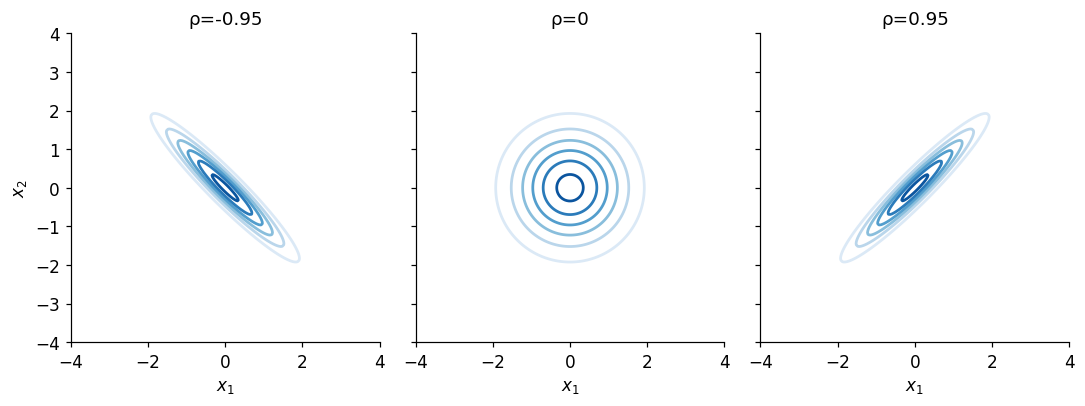

In [4]:
gaussian_grid = np.linspace(-4, 4, 201)
xx, yy = np.meshgrid(gaussian_grid, gaussian_grid)
points = np.stack((xx, yy), axis=-1)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), sharex=True, sharey=True)
for ax, rho in zip(axes, (-.95, 0, .95)):
    joint = stats.multivariate_normal([0, 0], [[1, rho], [rho, 1]])
    ax.contour(xx, yy, joint.pdf(points), levels=6, cmap="Blues")
    ax.set(title=f"ρ={rho:g}", xlabel="$x_1$", aspect="equal")
axes[0].set_ylabel("$x_2$")
fig.tight_layout()
plt.show()

### Conditional versus marginal Gaussian behavior

For illustration, I retain $\mu_1=\mu_2=0$, $\sigma_{11}=\sigma_{22}=1$ and $\rho=.8$. The course compares conditioning values $x_1=-3,0,3$. Their conditional means are $-.8\times3,0,.8\times3$, and their common variance is $.36$, compared with marginal variance one.

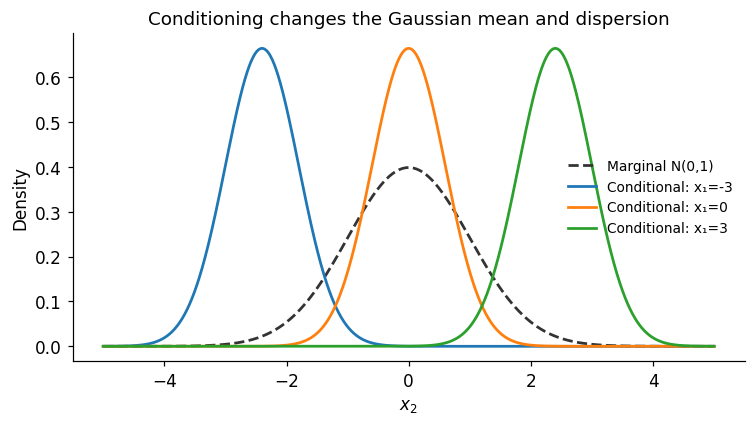

In [5]:
y_grid = np.linspace(-5, 5, 1001)
fig, ax = plt.subplots()
ax.plot(y_grid, stats.norm.pdf(y_grid), "--", color="0.2", label="Marginal N(0,1)")
for x1 in (-3, 0, 3):
    ax.plot(y_grid, stats.norm.pdf(y_grid, .8*x1, .6), label=f"Conditional: x₁={x1}")
ax.set(xlabel="$x_2$", ylabel="Density", title="Conditioning changes the Gaussian mean and dispersion")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 8. Financial mean–variance interpretation


For simple returns and weights fixed at the start of a common horizon,
$$R_p=w^\top\mathbf R,\qquad E[R_p]=w^\top\mu,\qquad \operatorname{Var}(R_p)=w^\top\Sigma w.$$
A weighted sum of asset log returns is not generally the exact portfolio log return.

The mean vector and covariance matrix are therefore the statistical foundation of mean–variance analysis. For two equally weighted assets with the same volatility $\sigma$,
$$\operatorname{Var}(R_p)=\frac{\sigma^2}{2}(1+\rho).$$
For illustration, I hold both expected returns at $.001$ and both volatilities at $.02$. Changing correlation changes portfolio variance without changing expected return. No portfolio-choice problem is solved.

In [6]:
weights = np.array([.5, .5])
asset_means = np.array([.001, .001])
asset_sd = .02
rows = []
for rho in (-.5, 0, .5, 1):
    asset_covariance = asset_sd**2*np.array([[1, rho], [rho, 1]])
    rows.append([rho, linear_combination_mean(weights, asset_means), linear_combination_variance(weights, asset_covariance)])
display(pd.DataFrame(rows, columns=["Correlation", "Portfolio expected return", "Portfolio variance"]))

,Correlation,Portfolio expected return,Portfolio variance
0,-0.5,0.001,0.0001
1,0.0,0.001,0.0002
2,0.5,0.001,0.0003
3,1.0,0.001,0.0004


## 9. Population versus finite sample

The population quantities $\mu$ and $\Sigma$ are fixed. An observed sample instead supplies $\bar x$ and
$$\widehat\Sigma=\frac1{n-1}\sum_{i=1}^n(x_i-\bar x)(x_i-\bar x)^\top.$$
These sample moments vary across iid samples of the same random vector. Independence across observations does not require independence between components.

For illustration, I draw 1000 independent Gaussian samples at each $n=20,100,1000$, with mean zero, unit marginal variances, correlation $.6$ and seed 211. The table compares sample mean, variance, covariance and correlation with their population targets. The figure focuses on covariance, which enters portfolio variance directly. The 10th and 90th percentiles describe simulation replications, rather than confidence intervals.

In [7]:
rng_repeated = np.random.default_rng(211)
replications = 1000
sample_sizes = (20, 100, 1000)
true_sigma = np.array([[1., 0.6], [0.6, 1.]])
repeated_matrices = {}
repeated_correlations = {}
repeated_means = {}
for n in sample_sizes:
    standard_samples = rng_repeated.normal(size=(replications, n, 2))
    samples = np.stack((standard_samples[:, :, 0],
                        0.6*standard_samples[:, :, 0]+0.8*standard_samples[:, :, 1]), axis=-1)
    repeated_means[n] = np.mean(samples, axis=1)
    repeated_matrices[n] = np.array([covariance_matrix(row) for row in samples])
    repeated_correlations[n] = np.array([correlation(row[:, 0], row[:, 1]) for row in samples])

print("Population covariance matrix:\n", true_sigma)
print("n      quantity       population   replication average   10th percentile   90th percentile")
for n in sample_sizes:
    matrix_values = repeated_matrices[n]
    summaries = (("mean X₁", repeated_means[n][:, 0], 0),
                 ("mean X₂", repeated_means[n][:, 1], 0),
                 ("variance X₁", matrix_values[:, 0, 0], 1),
                 ("variance X₂", matrix_values[:, 1, 1], 1),
                 ("covariance", matrix_values[:, 0, 1], 0.6),
                 ("correlation", repeated_correlations[n], 0.6))
    for name, values, truth in summaries:
        lower, upper = np.quantile(values, [0.10, 0.90])
        print(f"{n:4d}   {name:12s}     {truth:.3f}           {sample_mean(values):.4f}             {lower:.4f}            {upper:.4f}")

Population covariance matrix:
 [[1.  0.6]
 [0.6 1. ]]
n      quantity       population   replication average   10th percentile   90th percentile
  20   mean X₁          0.000           -0.0100             -0.3056            0.2632
  20   mean X₂          0.000           -0.0057             -0.2929            0.2800
  20   variance X₁      1.000           1.0009             0.6258            1.4331
  20   variance X₂      1.000           1.0079             0.6263            1.4447
  20   covariance       0.600           0.6059             0.2860            0.9615
  20   correlation      0.600           0.5946             0.3946            0.7669
 100   mean X₁          0.000           -0.0004             -0.1231            0.1322
 100   mean X₂          0.000           -0.0012             -0.1285            0.1268
 100   variance X₁      1.000           0.9956             0.8227            1.1695
 100   variance X₂      1.000           0.9990             0.8148            1.1807
 100   

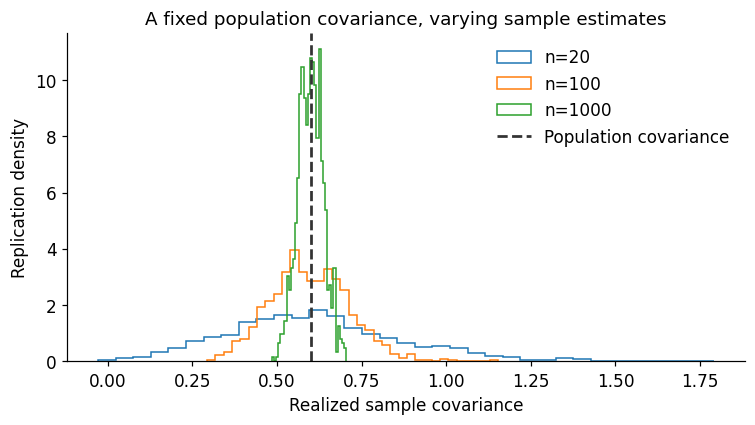

In [8]:
fig, ax = plt.subplots()
for n in sample_sizes:
    ax.hist(repeated_matrices[n][:, 0, 1], bins=35, density=True, histtype="step", label=f"n={n}")
ax.axvline(.6, color="0.2", linestyle="--", label="Population covariance")
ax.set(xlabel="Realized sample covariance", ylabel="Replication density", title="A fixed population covariance, varying sample estimates")
ax.legend()
fig.tight_layout()
plt.show()

A small sample can give a poor description of dependence. Substituting estimated moments into $w^\top\mu$ and $w^\top\Sigma w$ therefore carries uncertainty into the financial assessment. The population identities remain valid, but their inputs are not known exactly from observed returns.